In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

In [6]:
# Load regression dataset
df = pd.read_csv('student_regression.csv')
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
353,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
354,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
355,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [7]:
# Encode categoricals
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include = 'object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

df_encoded.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,6,5,6,6
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,4,5,5,6
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,10,7,8,10
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,2,15,14,15
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,4,6,10,10


In [8]:
# Features and target
X = df_encoded.drop(columns = ['G3'])
y = df_encoded['G3']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

# Compare linear vs polynomial on real data
print(" Degree | Train R²  | Test R²   | Diagnosis")
print("--------|-----------|-----------|------------------")
print()

for degree in [1,2,3]:
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree = degree, include_bias = False)),
        ('lr', LinearRegression())
        
    ])
    pipeline.fit(X_train, y_train)
    tr2 = r2_score(y_train, pipeline.predict(X_train))
    te2 = r2_score(y_test, pipeline.predict(X_test))

    gap = tr2 - te2
    if gap > 0.15:
        diagnosis='Overfitting ❌'
    elif tr2 < 0.6:
        diagnosis='Underfitting ⚠️'
    else:
        diagnosis='Good ✅'

    
    print(f"   {degree}    |   {tr2:.4f}  |   {te2:.4f}  | {diagnosis}")    
    

 Degree | Train R²  | Test R²   | Diagnosis
--------|-----------|-----------|------------------

   1    |   0.9439  |   0.9181  | Good ✅
   2    |   1.0000  |   0.6215  | Overfitting ❌
   3    |   1.0000  |   0.1873  | Overfitting ❌


In [21]:
best_degree = 1

# Build final model with best degree
final_model = Pipeline([
    ('poly', PolynomialFeatures(degree = best_degree, include_bias = False)),
    ('lr', LinearRegression())
])
final_model.fit(X_train, y_train)

# Prediction on test students
y_pred = final_model.predict(X_test)

# Comparison table
results = pd.DataFrame({
    'Actual_Grade': y_test.values,
    'Predicted_Grade': y_pred.round(1),
    'Error': (y_test.values - y_pred).round(2)
})

print("\nActual vs Predicted Grades:")
print(results.to_string(index=False))


Actual vs Predicted Grades:
 Actual_Grade  Predicted_Grade  Error
           12             12.5  -0.46
           18             18.2  -0.23
           11             11.1  -0.09
            9              9.5  -0.45
           15             15.6  -0.63
            9              6.8   2.25
           14             14.4  -0.37
           15             14.6   0.42
            9              8.7   0.34
            8              7.2   0.81
            6              6.0  -0.02
            5              4.9   0.11
           12             11.9   0.14
           11             10.6   0.43
           13             13.0  -0.01
           11             10.2   0.76
           11             11.1  -0.05
           13             13.6  -0.62
           14             12.4   1.59
           16             15.6   0.42
           10             10.4  -0.41
           12             11.2   0.75
            9              9.0   0.00
           12             10.2   1.78
           16        

In [22]:
# How far off is the model on average
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nOn average the model is off by: {rmse:.2f} grade points")


On average the model is off by: 0.89 grade points


In [19]:
# Predict on brand new student
new_student = X_test.iloc[[0]] # taking first test student as example
actual_grade = y_test.iloc[0]
predicted_grade = final_model.predict(new_student)[0]


print(f"\nSample Student:")
print(f"  Actual Grade    : {actual_grade}")
print(f"  Predicted Grade : {predicted_grade:.1f}")
print(f"  Error           : {abs(actual_grade - predicted_grade):.1f} points")


Sample Student:
  Actual Grade    : 12
  Predicted Grade : 12.5
  Error           : 0.5 points


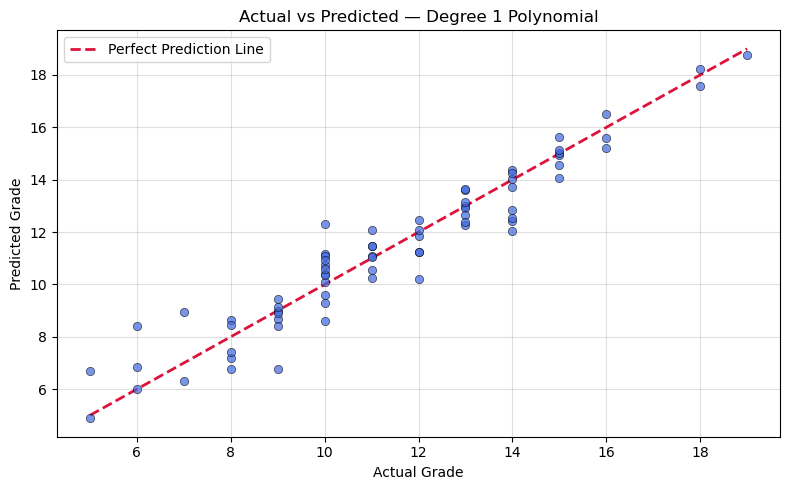

In [28]:
# Actual vs Predicted plot
plt.figure(figsize = (8,5))
plt.scatter(y_test, y_pred, color = 'royalblue', alpha = 0.7, edgecolor = 'k', linewidths = 0.5, zorder = 5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'crimson', linewidth = 2, linestyle = '--', label = 'Perfect Prediction Line')

plt.xlabel('Actual Grade')
plt.ylabel('Predicted Grade')
plt.title(f'Actual vs Predicted — Degree {best_degree} Polynomial')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()